In [1]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
class JokeState(TypedDict):
    topic: str
    joke: str
    explanation: str

In [3]:
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [4]:
def generate_joke(state: JokeState):
    prompt = f"Tell me a joke about: {state['topic']}"
    response = llm.invoke(prompt)
    return {"joke": response.content}

In [5]:
def generate_explanation(state: JokeState):
    prompt = f"Write an explanation for this joke: {state['joke']}"
    response = llm.invoke(prompt)
    return {"explanation": response.content}

In [6]:
graph = StateGraph(JokeState)
checkpointer = InMemorySaver()

graph.add_node("generate_joke", generate_joke)
graph.add_node("generate_explanation", generate_explanation)

graph.add_edge(START, "generate_joke")
graph.add_edge("generate_joke", "generate_explanation")
graph.add_edge("generate_explanation", END)

workflow = graph.compile(checkpointer=checkpointer)

In [7]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({"topic": "pizza"}, config1)

{'topic': 'pizza',
 'joke': 'Why was the pizza in a bad mood? Because it was feeling a little crusty.',
 'explanation': 'This joke is a play on words. The phrase "feeling a little crusty" has a double meaning here. In one sense, "crusty" refers to the outer layer of a pizza, which is known as the crust. However, "crusty" can also be used to describe someone who is irritable, gruff, or in a bad mood.\n\nThe joke relies on this wordplay to create humor. By saying the pizza is "feeling a little crusty," it\'s making a pun on the fact that pizza has a crust, but also implying that the pizza is in a bad mood, much like a person who is described as being "crusty." This clever use of language creates a lighthearted and amusing effect, making it a humorous joke.'}

In [8]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood? Because it was feeling a little crusty.', 'explanation': 'This joke is a play on words. The phrase "feeling a little crusty" has a double meaning here. In one sense, "crusty" refers to the outer layer of a pizza, which is known as the crust. However, "crusty" can also be used to describe someone who is irritable, gruff, or in a bad mood.\n\nThe joke relies on this wordplay to create humor. By saying the pizza is "feeling a little crusty," it\'s making a pun on the fact that pizza has a crust, but also implying that the pizza is in a bad mood, much like a person who is described as being "crusty." This clever use of language creates a lighthearted and amusing effect, making it a humorous joke.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13b23d-7d74-6f35-8002-4bd330c1fbce'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-04-18T12:

In [9]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood? Because it was feeling a little crusty.', 'explanation': 'This joke is a play on words. The phrase "feeling a little crusty" has a double meaning here. In one sense, "crusty" refers to the outer layer of a pizza, which is known as the crust. However, "crusty" can also be used to describe someone who is irritable, gruff, or in a bad mood.\n\nThe joke relies on this wordplay to create humor. By saying the pizza is "feeling a little crusty," it\'s making a pun on the fact that pizza has a crust, but also implying that the pizza is in a bad mood, much like a person who is described as being "crusty." This clever use of language creates a lighthearted and amusing effect, making it a humorous joke.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13b23d-7d74-6f35-8002-4bd330c1fbce'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-04-18T12

In [10]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({"topic": "pasta"}, config2)

{'topic': 'pasta',
 'joke': 'Why was the pasta in a bad mood. Because it was feeling a little "drained".',
 'explanation': 'This joke is a play on words, using a common phrase associated with emotions and giving it a clever twist related to pasta. \n\nThe phrase "feeling drained" typically means feeling exhausted, depleted of energy, or emotionally spent. However, in the context of pasta, "drained" has a literal meaning - after cooking, pasta is often drained of excess water. \n\nThe joke relies on this double meaning of the word "drained" to create a pun. The setup "Why was the pasta in a bad mood?" primes the listener to expect a reason related to emotions, but the punchline "Because it was feeling a little \'drained\'" subverts this expectation by using the word in a way that\'s both a common emotional state and a specific action related to cooking pasta. This wordplay creates the humor in the joke.'}

In [11]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'pasta', 'joke': 'Why was the pasta in a bad mood. Because it was feeling a little "drained".', 'explanation': 'This joke is a play on words, using a common phrase associated with emotions and giving it a clever twist related to pasta. \n\nThe phrase "feeling drained" typically means feeling exhausted, depleted of energy, or emotionally spent. However, in the context of pasta, "drained" has a literal meaning - after cooking, pasta is often drained of excess water. \n\nThe joke relies on this double meaning of the word "drained" to create a pun. The setup "Why was the pasta in a bad mood?" primes the listener to expect a reason related to emotions, but the punchline "Because it was feeling a little \'drained\'" subverts this expectation by using the word in a way that\'s both a common emotional state and a specific action related to cooking pasta. This wordplay creates the humor in the joke.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoin

In [12]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why was the pasta in a bad mood. Because it was feeling a little "drained".', 'explanation': 'This joke is a play on words, using a common phrase associated with emotions and giving it a clever twist related to pasta. \n\nThe phrase "feeling drained" typically means feeling exhausted, depleted of energy, or emotionally spent. However, in the context of pasta, "drained" has a literal meaning - after cooking, pasta is often drained of excess water. \n\nThe joke relies on this double meaning of the word "drained" to create a pun. The setup "Why was the pasta in a bad mood?" primes the listener to expect a reason related to emotions, but the punchline "Because it was feeling a little \'drained\'" subverts this expectation by using the word in a way that\'s both a common emotional state and a specific action related to cooking pasta. This wordplay creates the humor in the joke.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoi

### **1.) Short Term Memory**

### **2.) Fault Tolerance**

In [13]:
import time

In [14]:
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str
    step3: str

In [15]:
def step1(state: CrashState):
    print("Step 1 executed")
    return {"step1": "done", "input": state["input"]}

def step2(state: CrashState):
    print("Step 2 hanging ... now manually interrupt the process")
    time.sleep(30)
    return {"step2": "done"}

def step3(state: CrashState):
    print("Step 3 executed")
    return {"step3": "done"}

In [16]:
builder = StateGraph(CrashState)

builder.add_node("step1", step1)
builder.add_node("step2", step2)
builder.add_node("step3", step3)

builder.add_edge(START, "step1")
builder.add_edge("step1", "step2")
builder.add_edge("step2", "step3")
builder.add_edge("step3", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

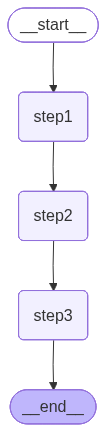

In [17]:
graph

In [18]:
try:
    print("Running graph ... Please manually interrupt the process at step 2")
    graph.invoke({"input": "start"}, config={"configurable": {"thread_id": "1"}})
except KeyboardInterrupt:
    print("Kernel Interrupted (Crash Simulation)")

Running graph ... Please manually interrupt the process at step 2
Step 1 executed
Step 2 hanging ... now manually interrupt the process
Kernel Interrupted (Crash Simulation)


In [19]:
graph.get_state(config={"configurable": {"thread_id": "1"}})

StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step2',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13b23d-914a-6f3c-8001-f338a5626bcf'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-04-18T12:40:57.709018+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13b23d-9145-6b2c-8000-865a43223884'}}, tasks=(PregelTask(id='33300dff-1cc8-6953-95a2-fe9969911421', name='step2', path=('__pregel_pull', 'step2'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [20]:
list(graph.get_state_history(config={"configurable": {"thread_id": "1"}}))

[StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step2',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13b23d-914a-6f3c-8001-f338a5626bcf'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-04-18T12:40:57.709018+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13b23d-9145-6b2c-8000-865a43223884'}}, tasks=(PregelTask(id='33300dff-1cc8-6953-95a2-fe9969911421', name='step2', path=('__pregel_pull', 'step2'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'input': 'start'}, next=('step1',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13b23d-9145-6b2c-8000-865a43223884'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-04-18T12:40:57.708010+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13b23d-9143-624

In [21]:
final_state = graph.invoke(None, config={"configurable": {"thread_id": "1"}})
final_state

Step 2 hanging ... now manually interrupt the process
Step 3 executed


{'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}

In [22]:
graph.get_state({"configurable": {"thread_id": "1"}})

StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13b240-3ecf-66fd-8003-91868fbd9e60'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-04-18T12:42:09.591884+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13b240-3ecc-6eb9-8002-5b8cdea7140a'}}, tasks=(), interrupts=())

In [23]:
list(graph.get_state_history(config={"configurable": {"thread_id": "1"}}))

[StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13b240-3ecf-66fd-8003-91868fbd9e60'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-04-18T12:42:09.591884+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13b240-3ecc-6eb9-8002-5b8cdea7140a'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done'}, next=('step3',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13b240-3ecc-6eb9-8002-5b8cdea7140a'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-04-18T12:42:09.589242+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13b23d-914a-6f3c-8001-f338a5626bcf'}}, tasks=(PregelTask(id='5865efcd-da2b-10bf-bfa0-f0a654805216', name='st

### **3.) Human in the loop**

### **4.) Time Travel**

In [26]:
workflow.get_state(config={"configurable": {"thread_id": "1", "checkpoint_id": "1f13b23d-72c9-60af-8000-2a446efdf165"}})

StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f13b23d-72c9-60af-8000-2a446efdf165'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-04-18T12:40:54.511223+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13b23d-72c7-6ce8-bfff-dc3e6fb568ef'}}, tasks=(PregelTask(id='4a3c7022-099e-ce46-99d1-a14394869e66', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why was the pizza in a bad mood? Because it was feeling a little crusty.'}),), interrupts=())

In [27]:
workflow.invoke(None, config={"configurable": {"thread_id": "1", "checkpoint_id": "1f13b23d-72c9-60af-8000-2a446efdf165"}})

{'topic': 'pizza',
 'joke': 'Why was the pizza in a bad mood? Because it was feeling a little crusty.',
 'explanation': 'This joke is a play on words, using a common phrase "feeling a little crusty" in a punny way. \n\nThe phrase "feeling a little crusty" is typically used to describe someone who is being irritable, grumpy, or a bit rough around the edges. However, in the context of this joke, "crusty" has a double meaning. A pizza has a crust, which is the outer layer of the bread, so the joke is making a clever connection between the phrase and the physical characteristics of a pizza.\n\nThe humor comes from the unexpected twist on the usual meaning of the phrase, and the clever use of wordplay to create a pun. The joke relies on the listener being familiar with the common phrase, and then subverting their expectations by applying it to a pizza in a literal sense. The result is a lighthearted and amusing joke that brings a smile to the listener\'s face.'}

In [28]:
list(workflow.get_state_history(config={"configurable": {"thread_id": "1"}}))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood? Because it was feeling a little crusty.', 'explanation': 'This joke is a play on words, using a common phrase "feeling a little crusty" in a punny way. \n\nThe phrase "feeling a little crusty" is typically used to describe someone who is being irritable, grumpy, or a bit rough around the edges. However, in the context of this joke, "crusty" has a double meaning. A pizza has a crust, which is the outer layer of the bread, so the joke is making a clever connection between the phrase and the physical characteristics of a pizza.\n\nThe humor comes from the unexpected twist on the usual meaning of the phrase, and the clever use of wordplay to create a pun. The joke relies on the listener being familiar with the common phrase, and then subverting their expectations by applying it to a pizza in a literal sense. The result is a lighthearted and amusing joke that brings a smile to the listener\'s face.'}, next=()

### Updating the state

In [30]:
workflow.update_state(config={"configurable": {"thread_id": "1", "checkpoint_id": "1f13b23d-72c9-60af-8000-2a446efdf165", "checkpoint_ns": ""}}, values={"topic": "ice cream"})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f13b254-b407-6ffb-8001-19205b8f7a21'}}

In [31]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'ice cream'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13b254-b407-6ffb-8001-19205b8f7a21'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-04-18T12:51:18.754303+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13b23d-72c9-60af-8000-2a446efdf165'}}, tasks=(PregelTask(id='ffcb83c0-e942-7f10-beaf-2250c69da9a5', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood? Because it was feeling a little crusty.', 'explanation': 'This joke is a play on words, using a common phrase "feeling a little crusty" in a punny way. \n\nThe phrase "feeling a little crusty" is typically used to describe someone who is being irritable, grumpy, or a bit rough around the edges

In [32]:
workflow.invoke(None, config={"configurable": {"thread_id": "1", 'checkpoint_ns': '', 'checkpoint_id': '1f13b254-b407-6ffb-8001-19205b8f7a21'}})

{'topic': 'ice cream',
 'joke': 'Why was the ice cream in a bad mood. Because it had a meltdown.',
 'explanation': 'This joke is a play on words, using the phrase "meltdown" in a double sense. \n\nIn a literal sense, a meltdown refers to the process of something, especially a solid like ice cream, changing state and turning into a liquid due to an increase in temperature. Ice cream can melt when it\'s exposed to warm temperatures, losing its shape and becoming a puddle.\n\nHowever, in a figurative sense, a meltdown can also refer to a person or thing experiencing a strong emotional outburst, often characterized by feelings of overwhelm, anxiety, or frustration. For example, someone might say, "I had a meltdown during the exam because I was so stressed."\n\nIn this joke, the phrase "meltdown" is used to make a humorous connection between the ice cream\'s physical state (melting) and its emotional state (being in a bad mood). The punchline "because it had a meltdown" is funny because it 

In [33]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'ice cream', 'joke': 'Why was the ice cream in a bad mood. Because it had a meltdown.', 'explanation': 'This joke is a play on words, using the phrase "meltdown" in a double sense. \n\nIn a literal sense, a meltdown refers to the process of something, especially a solid like ice cream, changing state and turning into a liquid due to an increase in temperature. Ice cream can melt when it\'s exposed to warm temperatures, losing its shape and becoming a puddle.\n\nHowever, in a figurative sense, a meltdown can also refer to a person or thing experiencing a strong emotional outburst, often characterized by feelings of overwhelm, anxiety, or frustration. For example, someone might say, "I had a meltdown during the exam because I was so stressed."\n\nIn this joke, the phrase "meltdown" is used to make a humorous connection between the ice cream\'s physical state (melting) and its emotional state (being in a bad mood). The punchline "because it had a meltdown" 